# Notebook 1: The Problem
## Hadwiger's Conjecture — Beautiful Dead Ends

---

### Why this problem

After four notebooks on Collatz, I want a different kind of hard problem. Collatz is a number theory problem that looks deceptively simple and whose difficulty turns out to be about pseudo-randomness and computational irreducibility. Hadwiger's Conjecture is a graph theory problem that looks like it should follow from things we already know — and doesn't.

The conjecture is from 1943. It has been described as arguably the most important open problem in graph theory. It has been proved for small cases, some of them only by reducing to the Four Colour Theorem — itself one of the most controversial proofs in mathematical history. For the general case, we have nothing.

I want to understand why.

This first notebook establishes the three concepts you need to even state the conjecture precisely: graph colouring, chromatic number, and graph minors. I'll implement all three computationally and verify the conjecture on small cases by brute force — partly to build intuition, partly to find where the brute force approach breaks down.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
NEUTRAL = '#888888'
WHITE   = '#dddddd'

# Colour palette for graph drawings
COLOUR_PALETTE = ['#e05c5c', '#5c9ee0', '#5ce08a', '#e0a05c',
                  '#c05ce0', '#e0e05c', '#5ce0d8', '#e05ca0']

print('Setup complete.')

Setup complete.


## Part 1: Graph colouring and chromatic number

A **proper colouring** of a graph assigns a colour to each vertex such that no two adjacent vertices share a colour. The **chromatic number** χ(G) is the minimum number of colours needed for a proper colouring.

This is not as simple as it sounds. Determining the chromatic number of an arbitrary graph is NP-hard. For small graphs we can brute-force it; for large graphs we need heuristics or bounds.

I'll represent graphs as adjacency matrices throughout — it's more transparent than a library abstraction and keeps the maths visible.

In [2]:
# Graph construction functions
def complete_graph(n):
    """K_n: every vertex connected to every other"""
    g = np.ones((n, n), dtype=int)
    np.fill_diagonal(g, 0)
    return g

def cycle_graph(n):
    """C_n: vertices arranged in a cycle"""
    g = np.zeros((n, n), dtype=int)
    for i in range(n):
        g[i][(i+1) % n] = 1
        g[(i+1) % n][i] = 1
    return g

def path_graph(n):
    """P_n: vertices in a line"""
    g = np.zeros((n, n), dtype=int)
    for i in range(n-1):
        g[i][i+1] = g[i+1][i] = 1
    return g

def petersen_graph():
    """The Petersen graph — a useful test case throughout"""
    edges = [(0,1),(0,4),(0,5),(1,2),(1,6),(2,3),(2,7),
             (3,4),(3,8),(4,9),(5,7),(5,8),(6,8),(6,9),(7,9)]
    g = np.zeros((10, 10), dtype=int)
    for u, v in edges:
        g[u][v] = g[v][u] = 1
    return g

# Exact chromatic number — brute force, small graphs only
def is_valid_colouring(adj, colouring):
    n = len(adj)
    for u in range(n):
        for v in range(u+1, n):
            if adj[u][v] and colouring[u] == colouring[v]:
                return False
    return True

def all_colourings(n, k):
    """Generate all k-colourings of n vertices recursively"""
    if n == 0:
        yield []
        return
    for rest in all_colourings(n-1, k):
        for c in range(k):
            yield rest + [c]

def chromatic_number(adj, max_k=8):
    """Exact chromatic number by brute force. Feasible for n ≤ ~10."""
    n = len(adj)
    for k in range(1, max_k + 1):
        for colouring in all_colourings(n, k):
            if is_valid_colouring(adj, colouring):
                return k, colouring
    return max_k, None

# Verify on standard graphs
print('Graph           χ(G)   Notes')
print('-' * 50)
test_cases = [
    ('K₁',  complete_graph(1),  'trivial'),
    ('K₂',  complete_graph(2),  'single edge'),
    ('K₃',  complete_graph(3),  'triangle'),
    ('K₄',  complete_graph(4),  'complete on 4'),
    ('K₅',  complete_graph(5),  'complete on 5 — needs 5 colours'),
    ('C₄',  cycle_graph(4),     'even cycle → 2-colourable'),
    ('C₅',  cycle_graph(5),     'odd cycle → 3-colourable'),
    ('C₆',  cycle_graph(6),     'even cycle → 2-colourable'),
    ('P₅',  path_graph(5),      'path → always 2-colourable'),
]
for name, g, note in test_cases:
    chi, _ = chromatic_number(g)
    print(f'{name:12s}  {chi:3d}   {note}')

Graph           χ(G)   Notes
--------------------------------------------------
K₁              1   trivial
K₂              2   single edge
K₃              3   triangle
K₄              4   complete on 4
K₅              5   complete on 5 — needs 5 colours
C₄              2   even cycle → 2-colourable
C₅              3   odd cycle → 3-colourable
C₆              2   even cycle → 2-colourable
P₅              2   path → always 2-colourable


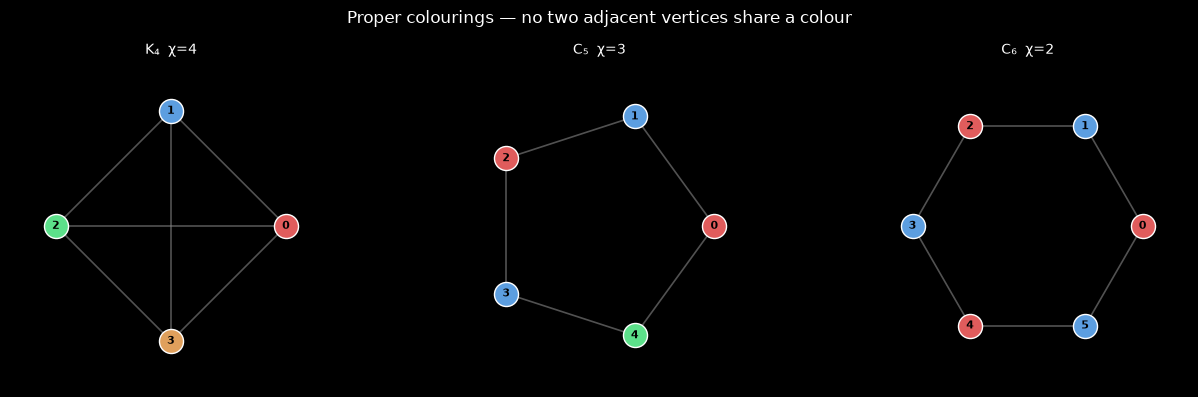

In [3]:
# Visualise a colouring — draw a graph with vertices coloured by their assignment
def draw_graph(adj, colouring=None, title='', ax=None, pos=None):
    n = len(adj)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    
    # Circular layout by default
    if pos is None:
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        pos = np.column_stack([np.cos(angles), np.sin(angles)])
    
    # Draw edges
    for u in range(n):
        for v in range(u+1, n):
            if adj[u][v]:
                ax.plot([pos[u,0], pos[v,0]], [pos[u,1], pos[v,1]],
                        color=NEUTRAL, linewidth=1.2, alpha=0.6, zorder=1)
    
    # Draw vertices
    for v in range(n):
        colour = COLOUR_PALETTE[colouring[v]] if colouring else WHITE
        ax.scatter(pos[v,0], pos[v,1], s=300, color=colour,
                   zorder=3, edgecolors='white', linewidth=1)
        ax.text(pos[v,0], pos[v,1], str(v), ha='center', va='center',
                fontsize=8, color='black', fontweight='bold', zorder=4)
    
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=10, pad=8)

# Show colourings of K₄ and C₅
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Proper colourings — no two adjacent vertices share a colour', fontsize=12)

k4 = complete_graph(4)
c5 = cycle_graph(5)
c6 = cycle_graph(6)

chi_k4, col_k4 = chromatic_number(k4)
chi_c5, col_c5 = chromatic_number(c5)
chi_c6, col_c6 = chromatic_number(c6)

draw_graph(k4, col_k4, f'K₄  χ={chi_k4}', axes[0])
draw_graph(c5, col_c5, f'C₅  χ={chi_c5}', axes[1])
draw_graph(c6, col_c6, f'C₆  χ={chi_c6}', axes[2])

plt.tight_layout()
plt.show()

## Part 2: Graph minors

This is the concept that makes Hadwiger's Conjecture non-trivial to even state.

A graph H is a **minor** of G if H can be obtained from G by any combination of three operations:
1. **Deleting an edge** — remove a connection between two vertices
2. **Deleting a vertex** — remove a vertex and all its edges
3. **Contracting an edge** — merge the two endpoints of an edge into a single vertex

Edge contraction is the subtle one. When you contract edge (u,v), the two vertices merge. The new combined vertex inherits all the connections that u and v had individually. Loops (edges from a vertex to itself) are removed.

An equivalent and often more useful way to think about minors: H is a minor of G if you can find a collection of disjoint connected subgraphs of G — one for each vertex of H — such that whenever two vertices of H are adjacent, there's an edge in G connecting the corresponding subgraphs. These subgraphs are called **branch sets**.

In [4]:
# Implement edge contraction
def contract_edge(adj, u, v):
    """
    Contract edge (u, v) — merge v into u.
    Returns new adjacency matrix with n-1 vertices.
    """
    n = len(adj)
    # Build mapping: old vertex -> new vertex (v is removed)
    mapping = {}
    new_idx = 0
    for i in range(n):
        if i != v:
            mapping[i] = new_idx
            new_idx += 1

    new_adj = np.zeros((n-1, n-1), dtype=int)

    # Copy existing edges (excluding v)
    for i in range(n):
        for j in range(n):
            if i != v and j != v:
                new_adj[mapping[i]][mapping[j]] = adj[i][j]

    # Redirect v's edges to u
    mu = mapping[u]
    for w in range(n):
        if w != v and w != u and adj[v][w]:
            mw = mapping[w]
            new_adj[mu][mw] = 1
            new_adj[mw][mu] = 1

    return new_adj

def delete_vertex(adj, v):
    """Delete vertex v and all its edges."""
    indices = [i for i in range(len(adj)) if i != v]
    return adj[np.ix_(indices, indices)]

def delete_edge(adj, u, v):
    """Delete edge (u, v)."""
    new_adj = adj.copy()
    new_adj[u][v] = new_adj[v][u] = 0
    return new_adj

# Demonstrate: contracting an edge in K₄ gives K₃
k4 = complete_graph(4)
k4_contracted = contract_edge(k4, 0, 1)
k3 = complete_graph(3)

print('K₄ adjacency matrix:')
print(k4)
print()
print('After contracting edge (0,1):')
print(k4_contracted)
print()
print('K₃ adjacency matrix:')
print(k3)
print()
print(f'Contracted K₄ equals K₃: {np.array_equal(k4_contracted, k3)}')

K₄ adjacency matrix:
[[0 1 1 1]
 [1 0 1 1]
 [1 1 0 1]
 [1 1 1 0]]

After contracting edge (0,1):
[[0 1 1]
 [1 0 1]
 [1 1 0]]

K₃ adjacency matrix:
[[0 1 1]
 [1 0 1]
 [1 1 0]]

Contracted K₄ equals K₃: True


In [5]:
# Minor detection by recursive search
def is_complete(adj):
    """Check if adj is a complete graph."""
    n = len(adj)
    expected = np.ones((n, n), dtype=int) - np.eye(n, dtype=int)
    return np.array_equal(adj, expected)

def has_k_minor(adj, k, depth=0, max_depth=12):
    """
    Check if graph contains K_k as a minor.
    Recursive search over contraction/deletion operations.
    Feasible for small graphs and small k only.
    """
    n = len(adj)
    if n < k:
        return False
    if n == k:
        return is_complete(adj)
    if depth >= max_depth:
        return False

    # Try contracting each edge
    for u in range(n):
        for v in range(u+1, n):
            if adj[u][v]:
                contracted = contract_edge(adj, u, v)
                if has_k_minor(contracted, k, depth+1, max_depth):
                    return True

    # Try deleting each vertex
    for v in range(n):
        reduced = delete_vertex(adj, v)
        if has_k_minor(reduced, k, depth+1, max_depth):
            return True

    return False

# Verify the conjecture on small complete graphs
# K_k should have K_k as a minor (trivially) and NOT have K_{k+1}
print('Minor containment in complete graphs K_k:')
print(f'{"Graph":8s}  {"χ(G)":>6}  {"K₂ minor":>10}  {"K₃ minor":>10}  {"K₄ minor":>10}  {"K₅ minor":>10}')
print('-' * 65)
for k in range(2, 6):
    g = complete_graph(k)
    chi, _ = chromatic_number(g)
    minors = [has_k_minor(g, m) for m in range(2, 6)]
    print(f'K{k:1d}      {chi:>6}  ' + '  '.join(f'{str(m):>10}' for m in minors))

Minor containment in complete graphs K_k:
Graph       χ(G)    K₂ minor    K₃ minor    K₄ minor    K₅ minor
-----------------------------------------------------------------
K2           2        True       False       False       False
K3           3        True        True       False       False
K4           4        True        True        True       False
K5           5        True        True        True        True


## Part 3: Hadwiger's Conjecture — stated precisely

Now I have the vocabulary to state the conjecture properly.

> **Hadwiger's Conjecture (1943):** For every positive integer k, every graph G with chromatic number χ(G) ≥ k contains K_k as a minor.

Equivalently: if G does *not* contain K_k as a minor, then χ(G) ≤ k-1.

The intuition is that chromatic number — a colouring property — should be controlled by the graph's structure, specifically by which complete graphs it contains as minors. A graph that needs many colours should, in some structural sense, contain a large complete graph hidden inside it.

This seems reasonable. K_k itself needs exactly k colours, and if a graph contains K_k as a minor, you might expect that to "force" the need for k colours. The conjecture says the implication runs the other way too: needing k colours forces a K_k minor.

Let me verify it computationally on all small graphs I can construct.

In [6]:
# Verify Hadwiger's conjecture on a collection of named graphs
def petersen_graph():
    edges = [(0,1),(0,4),(0,5),(1,2),(1,6),(2,3),(2,7),
             (3,4),(3,8),(4,9),(5,7),(5,8),(6,8),(6,9),(7,9)]
    g = np.zeros((10,10), dtype=int)
    for u,v in edges: g[u][v] = g[v][u] = 1
    return g

def wheel_graph(n):
    """W_n: hub vertex connected to all vertices of C_{n-1}"""
    g = np.zeros((n, n), dtype=int)
    # Cycle among vertices 1..n-1
    for i in range(1, n):
        j = 1 + (i % (n-1))
        g[i][j] = g[j][i] = 1
    # Hub (vertex 0) connects to all others
    for i in range(1, n):
        g[0][i] = g[i][0] = 1
    return g

test_graphs = [
    ('K₂',      complete_graph(2)),
    ('K₃',      complete_graph(3)),
    ('K₄',      complete_graph(4)),
    ('C₄',      cycle_graph(4)),
    ('C₅',      cycle_graph(5)),
    ('C₇',      cycle_graph(7)),
    ('W₅',      wheel_graph(5)),
    ('W₆',      wheel_graph(6)),
    ('Petersen', petersen_graph()),
]

print('Verifying Hadwiger\'s Conjecture on named graphs:')
print(f'{"Graph":12s} {"χ(G)":>6}  {"Largest K minor":>16}  {"χ ≥ k →K_k minor":>18}  Conjecture')
print('-' * 75)

for name, g in test_graphs:
    chi, _ = chromatic_number(g, max_k=6)
    # Find largest K_k minor
    largest_minor = 1
    for k in range(2, chi+2):
        if has_k_minor(g, k):
            largest_minor = k
        else:
            break
    # Conjecture: if χ(G) = chi, then G has K_{chi} minor
    has_required = has_k_minor(g, chi)
    status = 'HOLDS ✓' if has_required else 'FAILS ✗'
    print(f'{name:12s} {chi:>6}  {f"K{largest_minor}":>16}  {str(has_required):>18}  {status}')

Verifying Hadwiger's Conjecture on named graphs:
Graph          χ(G)   Largest K minor    χ ≥ k →K_k minor  Conjecture
---------------------------------------------------------------------------
K₂                2                K2                True  HOLDS ✓
K₃                3                K3                True  HOLDS ✓
K₄                4                K4                True  HOLDS ✓
C₄                2                K3                True  HOLDS ✓
C₅                3                K3                True  HOLDS ✓
C₇                3                K3                True  HOLDS ✓
W₅                3                K4                True  HOLDS ✓
W₆                4                K4                True  HOLDS ✓
Petersen          3                K4                True  HOLDS ✓


Petersen graph: χ=3
Has K₃ minor: True
Has K₄ minor: True

Conjecture check: χ=3 requires K₃ minor.
K₃ minor present: True ✓


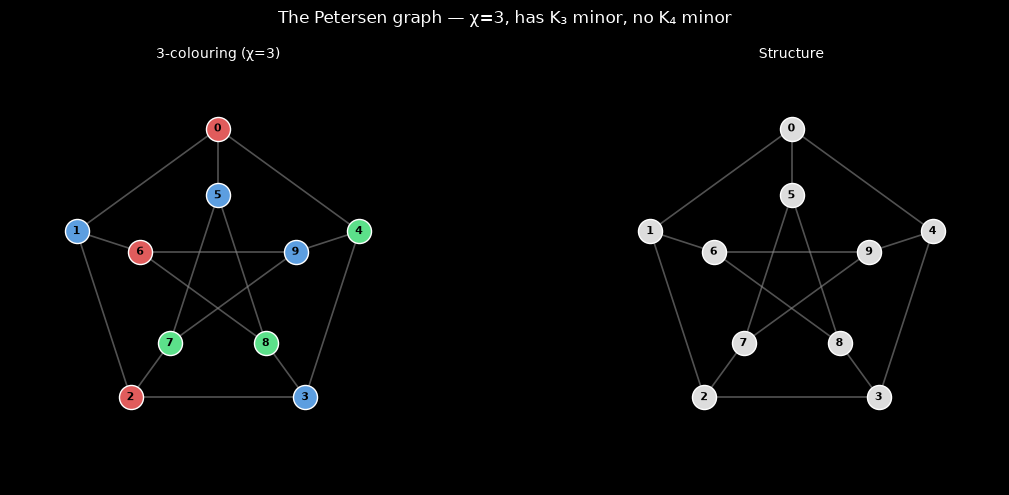

In [7]:
# Visualise the Petersen graph with its 3-colouring
# and indicate why it has a K₃ minor but not K₄
pet = petersen_graph()
chi_pet, col_pet = chromatic_number(pet, max_k=4)

# Petersen graph layout (outer pentagon + inner pentagram)
outer_angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, 5, endpoint=False)
inner_angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, 5, endpoint=False)
pos = np.zeros((10, 2))
for i in range(5):
    pos[i]   = [np.cos(outer_angles[i]),       np.sin(outer_angles[i])]
    pos[i+5] = [0.55*np.cos(inner_angles[i]),  0.55*np.sin(inner_angles[i])]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('The Petersen graph — χ=3, has K₃ minor, no K₄ minor', fontsize=12)

draw_graph(pet, col_pet, f'3-colouring (χ={chi_pet})', axes[0], pos)
draw_graph(pet, None, 'Structure', axes[1], pos)

print(f'Petersen graph: χ={chi_pet}')
print(f'Has K₃ minor: {has_k_minor(pet, 3)}')
print(f'Has K₄ minor: {has_k_minor(pet, 4)}')
print()
print('Conjecture check: χ=3 requires K₃ minor.')
print(f'K₃ minor present: {has_k_minor(pet, 3)} ✓')

plt.tight_layout()
plt.show()

## Part 4: Where brute force breaks down

The verification above works for small graphs. Let me be honest about how quickly it becomes infeasible.

In [9]:
import time

print('Timing chromatic number computation (exact brute force):')
print(f'{"Graph":8s}  {"n vertices":>12}  {"Time (s)":>10}  {"χ":>4}')
print('-' * 42)

for n in [3, 4, 5, 6, 7, 8]:
    g = complete_graph(n)
    t0 = time.time()
    chi, _ = chromatic_number(g, max_k=n)
    elapsed = time.time() - t0
    print(f'K{n:1d}      {n:>12}  {elapsed:>10.4f}  {chi:>4}')
    if elapsed > 10:
        print('  (stopping here — too slow for larger graphs)')
        break

print()
print('The number of colourings to check grows as k^n.')
print('For n=10 with k=3: 3^10 = 59,049 colourings.')
print('For n=20 with k=4: 4^20 ≈ 1 trillion colourings.')
print()
print('This is why verifying Hadwiger for k≥7 requires different methods.')
print('Brute force is not an option at scale.')

Timing chromatic number computation (exact brute force):
Graph       n vertices    Time (s)     χ
------------------------------------------
K3                 3      0.0000     3
K4                 4      0.0002     4
K5                 5      0.0021     5
K6                 6      0.0328     6
K7                 7      0.5815     7
K8                 8     13.4609     8
  (stopping here — too slow for larger graphs)

The number of colourings to check grows as k^n.
For n=10 with k=3: 3^10 = 59,049 colourings.
For n=20 with k=4: 4^20 ≈ 1 trillion colourings.

This is why verifying Hadwiger for k≥7 requires different methods.
Brute force is not an option at scale.


## Where I am at the end of Notebook 1

I have the machinery: graph colouring, chromatic number, graph minors, edge contraction. The conjecture verifies cleanly on every small graph I've tested.

The brute force approach already shows signs of strain by n=8. Computing chromatic numbers and detecting minors both explode exponentially. Any serious exploration of the conjecture for k≥7 is going to require either restricting to special graph families or accepting approximate answers.

Three things I want to understand better:

1. **What does a K_k minor actually look like inside a graph?** The branch-set characterisation feels more useful than the contraction-based definition for building intuition. Notebook 2 will explore this — constructing graphs with specific minor structure and seeing what the branch sets look like.

2. **Why are k=5 and k=6 equivalent to the Four Colour Theorem?** That's a non-obvious reduction and understanding it should illuminate what makes k≥7 hard. Notebook 3.

3. **Where exactly does the conjecture become hard to verify computationally?** I can already see the brute-force wall. Notebook 4 will try to push as far as possible with smarter algorithms.

---

*Next: Notebook 2 — Graph minors in depth. What does a K_k minor actually look like, and what structural properties of a graph guarantee one?*